In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

from data.loader import  load_data
from portfolio.portfolio import Strategy

In [2]:
prices = load_data(
    ["KO", "PEP"],
    "2020-01-01",
    "2026-01-01",
)

[*********************100%***********************]  2 of 2 completed


In [3]:
prices.head()

Price       Adj Close                  Close                   High  \
Ticker             KO         PEP         KO         PEP         KO   
Date                                                                  
2020-01-02  44.873501  109.772476  54.990002  135.820007  55.430000   
2020-01-03  44.628685  109.618904  54.689999  135.630005  54.990002   
2020-01-06  44.612366  110.039185  54.669998  136.149994  54.910000   
2020-01-07  44.269630  108.309555  54.250000  134.009995  54.599998   
2020-01-08  44.351227  108.867233  54.349998  134.699997  54.639999   

Price                         Low                   Open              \
Ticker             PEP         KO         PEP         KO         PEP   
Date                                                                   
2020-01-02  137.229996  54.759998  135.139999  55.320000  136.869995   
2020-01-03  136.789993  54.090000  135.130005  54.320000  135.460007   
2020-01-06  136.320007  54.520000  135.199997  54.650002  135.300003   
2020-01-07  136.070007  54.150002  133.949997  54.450001  136.000000   
2020-01-08  135.360001  54.150002  134.070007  54.270000  134.460007   

Price         Volume           
Ticker            KO      PEP  
Date                           
2020-01-02  11867700  3784100  
2020-01-03  11354500  4000100  
2020-01-06  14698300  4085100  
2020-01-07   9973900  5718100  
2020-01-08  10676000  3681400

In [4]:
close = prices['Close'].squeeze()

In [5]:
log_returns = np.log(close / close.shift(1)).dropna()

In [6]:
log_returns.describe()

Ticker,KO,PEP
count,1507.000000,1507.000000
mean,0.000159,0.000037
std,0.012856,0.014000
min,-0.101728,-0.121358
25%,-0.005714,-0.006041
50%,0.000493,0.000292
75%,0.006254,0.006647
max,0.062783,0.121656


In [7]:
log_returns.std()

Ticker
KO     0.012856
PEP    0.014000
dtype: float64

In [8]:
log_returns.skew()

Ticker
KO    -0.748022
PEP   -0.449667
dtype: float64

In [9]:
log_returns.kurtosis()

Ticker
KO      8.666301
PEP    17.860700
dtype: float64

### Simple spread with B = 1

In [10]:
spread = close["KO"] - close["PEP"]
spread

Date
2020-01-02   -80.830006
2020-01-03   -80.940006
2020-01-06   -81.479996
2020-01-07   -79.759995
2020-01-08   -80.349998
                ...    
2025-12-24   -73.630005
2025-12-26   -73.909996
2025-12-29   -74.080002
2025-12-30   -74.090004
2025-12-31   -73.610001
Length: 1508, dtype: float64

In [11]:
window = 60

mean = spread.rolling(window).mean()
std = spread.rolling(window).std()

z = (spread - mean) / std

z

Date
2020-01-02         NaN
2020-01-03         NaN
2020-01-06         NaN
2020-01-07         NaN
2020-01-08         NaN
                ...   
2025-12-24    1.030151
2025-12-26    0.936826
2025-12-29    0.876488
2025-12-30    0.864870
2025-12-31    0.992754
Length: 1508, dtype: float64

In [12]:
signal = pd.Series(0, index=z.index)
signal[z > 2] = -1
signal[z < -2] = 1

## Metrics


In [13]:
s = Strategy(["KO", "PEP"], "2020-01-01", "2026-01-01")
s.get_signals()
s.order()
print(s.backtest())
for name, x in [("train", s.pnl.iloc[:s.split]), ("test", s.pnl.iloc[s.split:])]:
    eq = (1 + x).cumprod()
    print(name, "sharpe", round(x.mean() / x.std() * np.sqrt(252), 2), "maxdd", round((eq / eq.cummax() - 1).min(), 3))

[*********************100%***********************]  2 of 2 completed

{'beta': np.float64(0.798855262907237), 'adf_p': 0.01772564893753482, 'coint_p': 0.0640421886229067, 'half_life': np.float64(33.35962667130302), 'window': 67, 'test_sharpe': np.float64(-0.4181925455949208), 'test_return': np.float64(-0.1138275204021606), 'test_trades': 11}
train sharpe 0.15 maxdd -0.192
test sharpe -0.42 maxdd -0.292



/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]


In [14]:
test_pairs = [['XOM', 'CVX'], ['V', 'MA'], ['HD', 'LOW'], ['GLD', 'GDX'], ['XLE', 'XOP'], ['JPM', 'BAC'], ['UPS', 'FDX']]

pnl = []
rows = []

for pair in test_pairs:
    try:
        s = Strategy(pair, '2020-01-01', '2026-01-01')
        s.get_signals()
        s.order()
        r = s.backtest()
        tr = s.pnl.iloc[:s.split]
        te = s.pnl.iloc[s.split:]

        equity = np.exp(s.pnl.fillna(0).cumsum())
        train_equity = np.exp(tr.fillna(0).cumsum())

        test_equity = np.exp(te.fillna(0).cumsum())
        test_equity = test_equity / test_equity.iloc[0]
        rows.append({
            "pair": "/".join(pair),
            "coint_p": round(r["coint_p"], 3),
            "half_life": round(r["half_life"], 1),
            "beta": round(r["beta"], 2),
            "train_sharpe": round(tr.mean() / tr.std() * np.sqrt(252), 2),
            "test_sharpe": round(r["test_sharpe"], 2),
            "test_trades": r["test_trades"],
            'equity': equity,
            'train_equity': train_equity,
            'test_equity': test_equity,
        })
    except Exception as e:
        print(pair, e)

pd.DataFrame(rows).sort_values("coint_p")

[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and sile

,pair,coint_p,half_life,beta,train_sharpe,test_sharpe,test_trades,equity,train_equity,test_equity
1,V/MA,0.027,16.8,0.83,0.84,0.03,18,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2023-08-07 1.00000 2023-08-08 1.000...
0,XOM/CVX,0.135,29.0,1.28,0.16,-0.51,8,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2023-08-07 1.000000 2023-08-08 1.00...
2,HD/LOW,0.273,33.8,0.60,0.34,-0.48,10,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2023-08-07 1.000000 2023-08-08 0.99...
3,GLD/GDX,0.364,44.0,0.28,0.05,-1.47,5,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2023-08-07 1.000000 2023-08-08 1.00...
6,UPS/FDX,0.609,96.9,0.72,0.39,-0.60,2,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2023-08-07 1.000000 2023-08-08 0.98...
4,XLE/XOP,0.712,51.0,0.82,0.20,0.57,9,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2023-08-07 1.000000 2023-08-08 0.99...
5,JPM/BAC,0.978,358.0,0.72,-0.50,-0.87,0,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2020-01-02 1.000000 2020-01-03 1.00...,Date 2023-08-07 1.000000 2023-08-08 0.99...


[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and sile

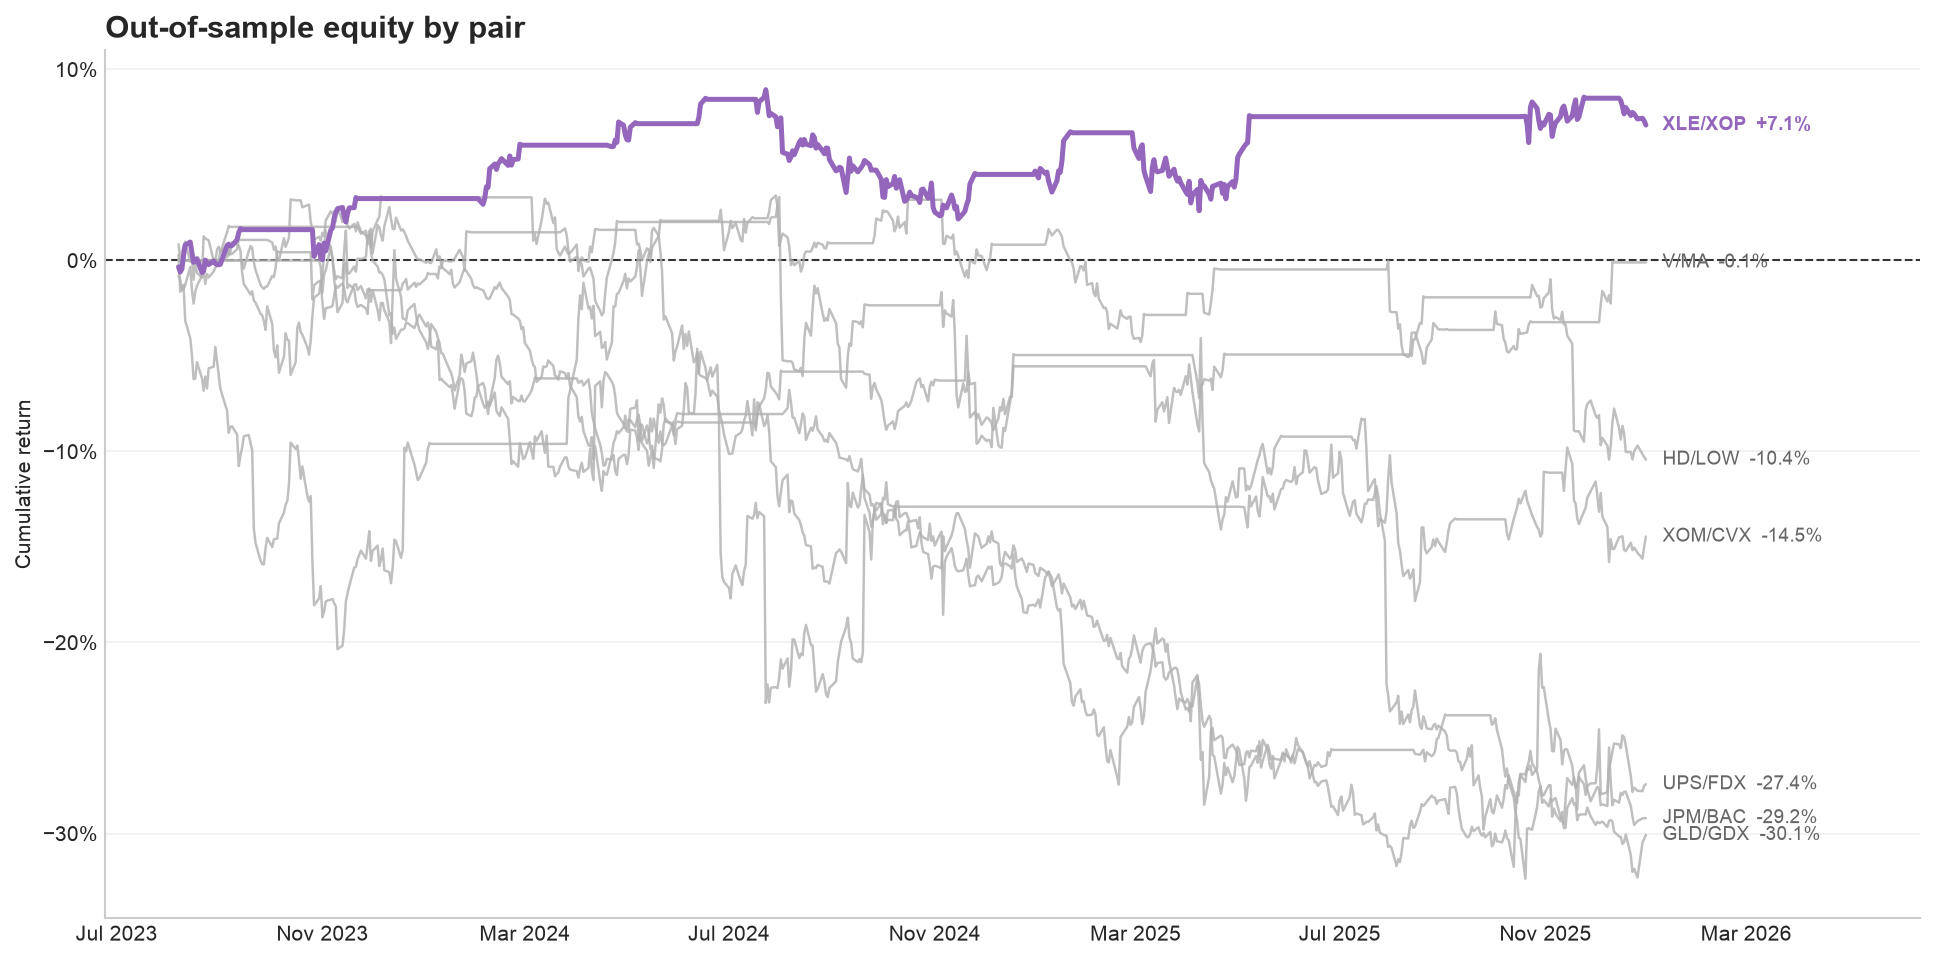

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

curves = {}
for pair in test_pairs:
    s = Strategy(pair, '2020-01-01', '2026-01-01')
    s.get_signals()
    s.order()
    s.backtest()
    curves["/".join(pair)] = (1 + s.pnl.iloc[s.split:]).cumprod() - 1

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(13, 6.5), dpi=150)

final = {k: v.iloc[-1] for k, v in curves.items()}
best = max(final, key=final.get)
palette = plt.cm.tab10.colors

for i, (name, eq) in enumerate(curves.items()):
    is_best = name == best
    ax.plot(
        eq.index, eq.values,
        color=palette[i] if is_best else "#b0b0b0",
        lw=2.4 if is_best else 1.2,
        alpha=1 if is_best else 0.8,
        zorder=3 if is_best else 2,
    )
    ax.annotate(
        f"{name}  {eq.iloc[-1]:+.1%}",
        xy=(eq.index[-1], eq.iloc[-1]),
        xytext=(8, 0), textcoords="offset points",
        va="center", fontsize=9,
        color=palette[i] if is_best else "#666666",
        fontweight="bold" if is_best else "normal",
    )

ax.axhline(0, color="#333333", lw=1, ls="--", zorder=1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_xlim(right=ax.get_xlim()[1] + 120)
ax.set_title("Out-of-sample equity by pair", loc="left", fontsize=15, fontweight="bold")
ax.set_ylabel("Cumulative return")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", alpha=0.3)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig("oos_equity.png", bbox_inches="tight")
plt.show()

[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and sile

   pair  coint_p  adf_p  half_life  test_sharpe  test_return  test_trades
   V/MA    0.027  0.007       16.8         0.14        0.022           18
XOM/CVX    0.135  0.045       29.0        -0.48       -0.132            8
 HD/LOW    0.273  0.113       33.8        -0.43       -0.091           10
GLD/GDX    0.364  0.165       44.0        -1.45       -0.341            5
UPS/FDX    0.609  0.361       96.9        -0.60       -0.274            2
XLE/XOP    0.712  0.473       51.0         0.65        0.081            9
JPM/BAC    0.978  0.936      358.0        -0.87       -0.317            0
         XOM/CVX  V/MA  HD/LOW  GLD/GDX  XLE/XOP  JPM/BAC  UPS/FDX
XOM/CVX     1.00 -0.01    0.09    -0.00     0.10    -0.03    -0.02
V/MA       -0.01  1.00   -0.06    -0.01    -0.06     0.08     0.05
HD/LOW      0.09 -0.06    1.00    -0.01     0.11    -0.05     0.02
GLD/GDX    -0.00 -0.01   -0.01     1.00    -0.04    -0.01     0.03
XLE/XOP     0.10 -0.06    0.11    -0.04     1.00    -0.05     0.00
JPM/BA


/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]


<Axes: title={'center': 'Equal-weight portfolio, out-of-sample'}, xlabel='Date'>

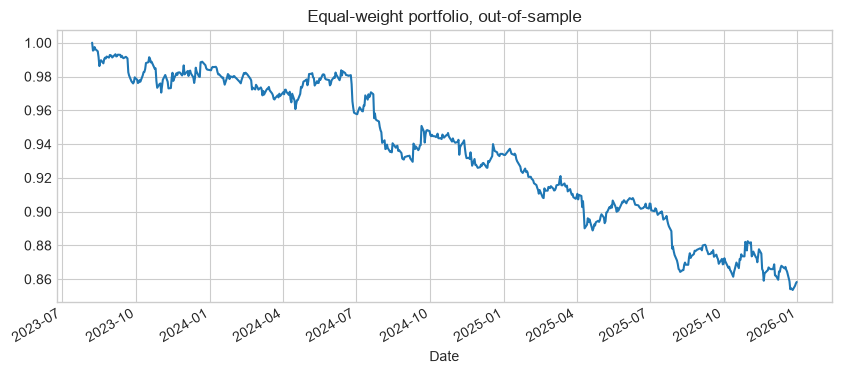

In [16]:
pnl = {}
rows = []

for pair in test_pairs:
    s = Strategy(pair, '2020-01-01', '2026-01-01', cost=0)
    s.get_signals()
    s.order()
    r = s.backtest()
    name = "/".join(pair)
    pnl[name] = s.pnl.iloc[s.split:]
    rows.append({
        'pair': name,
        'coint_p': round(r['coint_p'], 3),
        'adf_p': round(r['adf_p'], 3),
        'half_life': round(r['half_life'], 1),
        'test_sharpe': round(r['test_sharpe'], 2),
        'test_return': round(r['test_return'], 3),
        'test_trades': r['test_trades'],
    })

pnl = pd.DataFrame(pnl).dropna()
print(pd.DataFrame(rows).sort_values("coint_p").to_string(index=False))
print(pnl.corr().round(2))

port = pnl.mean(axis=1)
eq = (1 + port).cumprod()
print("portfolio sharpe", round(port.mean() / port.std() * np.sqrt(252), 2))
print("portfolio return", round(eq.iloc[-1] - 1, 3))
print("portfolio maxdd", round((eq / eq.cummax() - 1).min(), 3))
eq.plot(figsize=(10, 4), title="Equal-weight portfolio, out-of-sample")


In [17]:
s = Strategy(["XLE", "XOP"], "2020-01-01", "2026-01-01", use_kalman=True)
s.get_signals()
print(s.beta_t.describe())

[*********************100%***********************]  2 of 2 completed

count    1508.000000
mean        0.976428
std         0.212644
min         0.367370
25%         0.821313
50%         0.988812
75%         1.119506
max         1.479388
dtype: float64



/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]


In [18]:
rows = []
pnls = {False: {}, True: {}}

for pair in test_pairs:
    name = "/".join(pair)
    for k in [False, True]:
        s = Strategy(pair, '2020-01-01', '2026-01-01', use_kalman=k)
        s.get_signals()
        s.order()
        r = s.backtest()
        pnls[k][name] = s.pnl.iloc[s.split:]
        rows.append({
            "pair": name,
            "model": "kalman" if k else "static",
            "sharpe": round(r["test_sharpe"], 2),
            "return": round(r["test_return"], 3),
            "trades": r["test_trades"],
        })

print(pd.DataFrame(rows).pivot(index="pair", columns="model", values=["sharpe", "return", "trades"]).to_string())

for k in [False, True]:
    port = pd.DataFrame(pnls[k]).dropna().mean(axis=1)
    eq = (1 + port).cumprod()
    print("kalman" if k else "static",
          "sharpe", round(port.mean() / port.std() * np.sqrt(252), 2),
          "return", round(eq.iloc[-1] - 1, 3),
          "maxdd", round((eq / eq.cummax() - 1).min(), 3))

[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and sile

        sharpe        return        trades       
model   kalman static kalman static kalman static
pair                                             
GLD/GDX   0.41  -1.47  0.163 -0.346    5.0    5.0
HD/LOW   -0.40  -0.48 -0.062 -0.101   10.0   10.0
JPM/BAC   0.19  -0.87  0.080 -0.317    2.0    0.0
UPS/FDX   0.47  -0.60  0.527 -0.276    9.0    2.0
V/MA      0.16   0.03  0.020  0.004   23.0   18.0
XLE/XOP  -0.04   0.57 -0.007  0.072    9.0    9.0
XOM/CVX   0.23  -0.51  0.089 -0.140    8.0    8.0
static sharpe -1.45 return -0.148 maxdd -0.153
kalman sharpe 0.55 return 0.112 maxdd -0.103


In [19]:
s = Strategy(["XLE", "XOP"], "2020-01-01", "2026-01-01", use_kalman=True)
s.get_signals()
print(s.z_score.describe())

[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]


count    1407.000000
mean       -0.095914
std         1.363862
min        -4.239198
25%        -0.886124
50%        -0.110949
75%         0.802382
max         4.652056
dtype: float64


In [20]:
s = Strategy(["XLE", "XOP"], "2020-01-01", "2026-01-01", use_kalman=True)
s.get_signals()
z = s.z_score.dropna()
print("std", round(z.std(), 2), "max|z|", round(z.abs().max(), 2), "days>2", int((z.abs() > 2).sum()))

[*********************100%***********************]  2 of 2 completed


std 1.36 max|z| 4.65 days>2 197


/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]


In [21]:
for d in [1e-4, 1e-8]:
    pnls = {}
    for pair in test_pairs:
        s = Strategy(pair, '2020-01-01', '2026-01-01', use_kalman=True)
        s.get_signals()
        s.kalman_filter(delta=d)
        s.order()
        s.backtest()
        pnls["/".join(pair)] = s.pnl.iloc[s.split:]
        z = s.z_score.iloc[s.split:].dropna()
        print(d, "/".join(pair), "z_std", round(z.std(), 2), "max|z|", round(z.abs().max(), 2), "in_pos", round((s.positions.iloc[s.split:] != 0).mean(), 2))
    port = pd.DataFrame(pnls).dropna().mean(axis=1)
    print(d, "portfolio sharpe", round(port.mean() / port.std() * np.sqrt(252), 2))

[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]


0.0001 XOM/CVX z_std 1.29 max|z| 5.19 in_pos 0.27


[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[*********************100%***********************]  2 of 2 completed

0.0001 V/MA z_std 1.24 max|z| 4.24 in_pos 0.28



/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[*********************100%***********************]  2 of 2 completed

...


/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[***************

1e-08 V/MA z_std 4.61 max|z| 20.99 in_pos 0.42
1e-08 HD/LOW z_std 3.62 max|z| 14.48 in_pos 0.36
1e-08 GLD/GDX z_std 5.13 max|z| 23.68 in_pos 0.0


/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[****************

1e-08 XLE/XOP z_std 2.8 max|z| 13.39 in_pos 0.35
1e-08 JPM/BAC z_std 0.64 max|z| 4.2 in_pos 0.99
1e-08 UPS/FDX z_std 3.0 max|z| 11.79 in_pos 0.27
1e-08 portfolio sharpe -0.4



/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]


In [ ]:
pnls = {}
row = []

for pair in test_pairs:
    s = Strategy(pair, '2020-01-01', '2026-01-01')
    s.get_signals()
    s.order()
    r = s.backtest()
    t = s.pnl.iloc[s.split:]
    eq = (1 + t).cumprod()
    name = '/'.join(pair)
    pnls[name] = t

    rows.append({
        'pair': name,
        'sharpe': round(r['test_sharpe'], 2),
        'return':round(r['test_return'], 3),
        'max_dd': round((eq / eq.cummax() - 1).min(), 3),
        'test_trades': r['test_trades'],
    })

print(pd.DataFrame(rows).to_string(index=False))
p = pd.DataFrame(pnls).dropna().mean(axis=1)
e = (1 + p).cumprod()
print("portfolio sharpe", round(p.mean() / p.std() * np.sqrt(252), 2), "return", round(e.iloc[-1] - 1, 3), "maxdd", round((e / e.cummax() - 1).min(), 3))



[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and sile

   pair  model  sharpe  return  trades  max_dd  test_trades
XOM/CVX static   -0.51  -0.140     8.0     NaN          NaN
XOM/CVX kalman    0.23   0.089     8.0     NaN          NaN
   V/MA static    0.03   0.004    18.0     NaN          NaN
   V/MA kalman    0.16   0.020    23.0     NaN          NaN
 HD/LOW static   -0.48  -0.101    10.0     NaN          NaN
 HD/LOW kalman   -0.40  -0.062    10.0     NaN          NaN
GLD/GDX static   -1.47  -0.346     5.0     NaN          NaN
GLD/GDX kalman    0.41   0.163     5.0     NaN          NaN
XLE/XOP static    0.57   0.072     9.0     NaN          NaN
XLE/XOP kalman   -0.04  -0.007     9.0     NaN          NaN
JPM/BAC static   -0.87  -0.317     0.0     NaN          NaN
JPM/BAC kalman    0.19   0.080     2.0     NaN          NaN
UPS/FDX static   -0.60  -0.276     2.0     NaN          NaN
UPS/FDX kalman    0.47   0.527     9.0     NaN          NaN
XOM/CVX    NaN   -0.51  -0.140     NaN  -0.205          8.0
   V/MA    NaN    0.03   0.004     NaN  

/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]


In [26]:
pnls = {}
row = []

for pair in test_pairs:
    s = Strategy(pair, '2020-01-01', '2026-01-01', use_kalman=True)
    s.get_signals()
    s.order()
    r = s.backtest()
    t = s.pnl.iloc[s.split:]
    eq = (1 + t).cumprod()
    name = '/'.join(pair)
    pnls[name] = t

    rows.append({
        'pair': name,
        'sharpe': round(r['test_sharpe'], 2),
        'return':round(r['test_return'], 3),
        'max_dd': round((eq / eq.cummax() - 1).min(), 3),
        'test_trades': r['test_trades'],
    })

print(pd.DataFrame(rows).to_string(index=False))
p = pd.DataFrame(pnls).dropna().mean(axis=1)
e = (1 + p).cumprod()
print("portfolio sharpe", round(p.mean() / p.std() * np.sqrt(252), 2), "return", round(e.iloc[-1] - 1, 3), "maxdd", round((e / e.cummax() - 1).min(), 3))


[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and sile

   pair  model  sharpe  return  trades  max_dd  test_trades
XOM/CVX static   -0.51  -0.140     8.0     NaN          NaN
XOM/CVX kalman    0.23   0.089     8.0     NaN          NaN
   V/MA static    0.03   0.004    18.0     NaN          NaN
   V/MA kalman    0.16   0.020    23.0     NaN          NaN
 HD/LOW static   -0.48  -0.101    10.0     NaN          NaN
 HD/LOW kalman   -0.40  -0.062    10.0     NaN          NaN
GLD/GDX static   -1.47  -0.346     5.0     NaN          NaN
GLD/GDX kalman    0.41   0.163     5.0     NaN          NaN
XLE/XOP static    0.57   0.072     9.0     NaN          NaN
XLE/XOP kalman   -0.04  -0.007     9.0     NaN          NaN
JPM/BAC static   -0.87  -0.317     0.0     NaN          NaN
JPM/BAC kalman    0.19   0.080     2.0     NaN          NaN
UPS/FDX static   -0.60  -0.276     2.0     NaN          NaN
UPS/FDX kalman    0.47   0.527     9.0     NaN          NaN
XOM/CVX    NaN   -0.51  -0.140     NaN  -0.205          8.0
   V/MA    NaN    0.03   0.004     NaN  

In [28]:
pnls = {}
for pair in test_pairs:
    s = Strategy(pair, '2020-01-01', '2026-01-01', use_kalman=True)
    s.get_signals()
    s.order()
    s.backtest()
    pnls["/".join(pair)] = s.pnl.iloc[s.split:]

df = pd.DataFrame(pnls).dropna()

def stats(p):
    e = (1 + p).cumprod()
    return round(p.mean() / p.std() * np.sqrt(252), 2), round(e.iloc[-1] - 1, 3), round((e / e.cummax() - 1).min(), 3)

print("all", stats(df.mean(axis=1)))
print("ex UPS/FDX", stats(df.drop(columns="UPS/FDX").mean(axis=1)))
print(df.groupby(df.index.year).sum().round(3))

[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  self.adf_p = adfuller(train)[1]
[*********************100%***********************]  2 of 2 completed
/Users/sergheibigboy/quantlab_backtest/portfolio/portfolio.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and sile

all (np.float64(0.55), np.float64(0.112), np.float64(-0.103))
ex UPS/FDX (np.float64(0.33), np.float64(0.044), np.float64(-0.085))
      XOM/CVX   V/MA  HD/LOW  GLD/GDX  XLE/XOP  JPM/BAC  UPS/FDX
Date                                                            
2023   -0.011  0.020  -0.008   -0.005    0.000   -0.026    0.036
2024    0.119 -0.035  -0.019   -0.027    0.034   -0.069    0.575
2025   -0.019  0.036  -0.036    0.195   -0.041    0.174   -0.084
